# 🏏 IPL Business Analytics — Exploratory Data Analysis
### Framing: Insights for Franchise Owners & BCCI Strategists
**Author:** Your Name | **Dataset:** IPL 2008–2023 | **Tools:** Python, Pandas, Plotly, Seaborn

## 📌 Executive Summary
This notebook answers 5 core business questions using IPL ball-by-ball and match data:
1. Which franchises deliver consistent winning performance?
2. Where do matches actually get decided? (phase-wise analysis)
3. Does winning the toss give a real competitive edge?
4. Which venues favour batsmen vs bowlers?
5. Who are the most impactful (underrated) players by efficiency?

In [1]:
# ─── IMPORTS ───────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings("ignore")

# ─── STYLE CONFIG ──────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "#0d1117",
    "axes.facecolor": "#161b22",
    "axes.edgecolor": "#30363d",
    "axes.labelcolor": "#c9d1d9",
    "text.color": "#c9d1d9",
    "xtick.color": "#8b949e",
    "ytick.color": "#8b949e",
    "grid.color": "#21262d",
    "grid.linestyle": "--",
    "grid.alpha": 0.5,
    "font.family": "monospace",
    "figure.dpi": 130
})

IPL_COLORS = {
    "Mumbai Indians": "#004BA0",
    "Chennai Super Kings": "#F9CD05",
    "Royal Challengers Bangalore": "#EC1C24",
    "Kolkata Knight Riders": "#3A225D",
    "Sunrisers Hyderabad": "#F7A721",
    "Delhi Capitals": "#0078BC",
    "Rajasthan Royals": "#EA1A85",
    "Punjab Kings": "#ED1B24",
    "Lucknow Super Giants": "#A0E6FF",
    "Gujarat Titans": "#1C1C1C",
}

print("✅ Imports done. Ready to load data.")

✅ Imports done. Ready to load data.


In [2]:
# ─── LOAD DATA ─────────────────────────────────────────────────────────────
matches = pd.read_csv("../data/matches.csv")
deliveries = pd.read_csv("../data/deliveries.csv")

print(f"📊 matches.csv   → {matches.shape[0]:,} rows × {matches.shape[1]} cols")
print(f"📊 deliveries.csv → {deliveries.shape[0]:,} rows × {deliveries.shape[1]} cols")
matches.head(3)

📊 matches.csv   → 1,095 rows × 20 cols
📊 deliveries.csv → 260,920 rows × 17 cols


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar


In [3]:
# ─── DATA CLEANING ─────────────────────────────────────────────────────────

# Standardise team names (some datasets have old names)
name_map = {
    "Delhi Daredevils": "Delhi Capitals",
    "Kings XI Punjab": "Punjab Kings",
    "Deccan Chargers": "Sunrisers Hyderabad",
    "Rising Pune Supergiant": "Rising Pune Supergiants",
}
for col in ["team1", "team2", "winner", "toss_winner"]:
    if col in matches.columns:
        matches[col] = matches[col].replace(name_map)

for col in ["batting_team", "bowling_team"]:
    if col in deliveries.columns:
        deliveries[col] = deliveries[col].replace(name_map)

# Parse season
if "date" in matches.columns:
    matches["date"] = pd.to_datetime(matches["date"], errors="coerce")
    matches["season"] = matches["date"].dt.year
elif "season" not in matches.columns:
    matches["season"] = matches["id"].apply(lambda x: 2008)  # fallback

# Drop neutrals / no result
matches_clean = matches.dropna(subset=["winner"]).copy()

print(f"✅ Clean matches: {len(matches_clean):,} (removed {len(matches)-len(matches_clean)} no-result)")
print(f"   Seasons: {sorted(matches_clean['season'].unique())}")

✅ Clean matches: 1,090 (removed 5 no-result)
   Seasons: [np.int32(2008), np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024)]


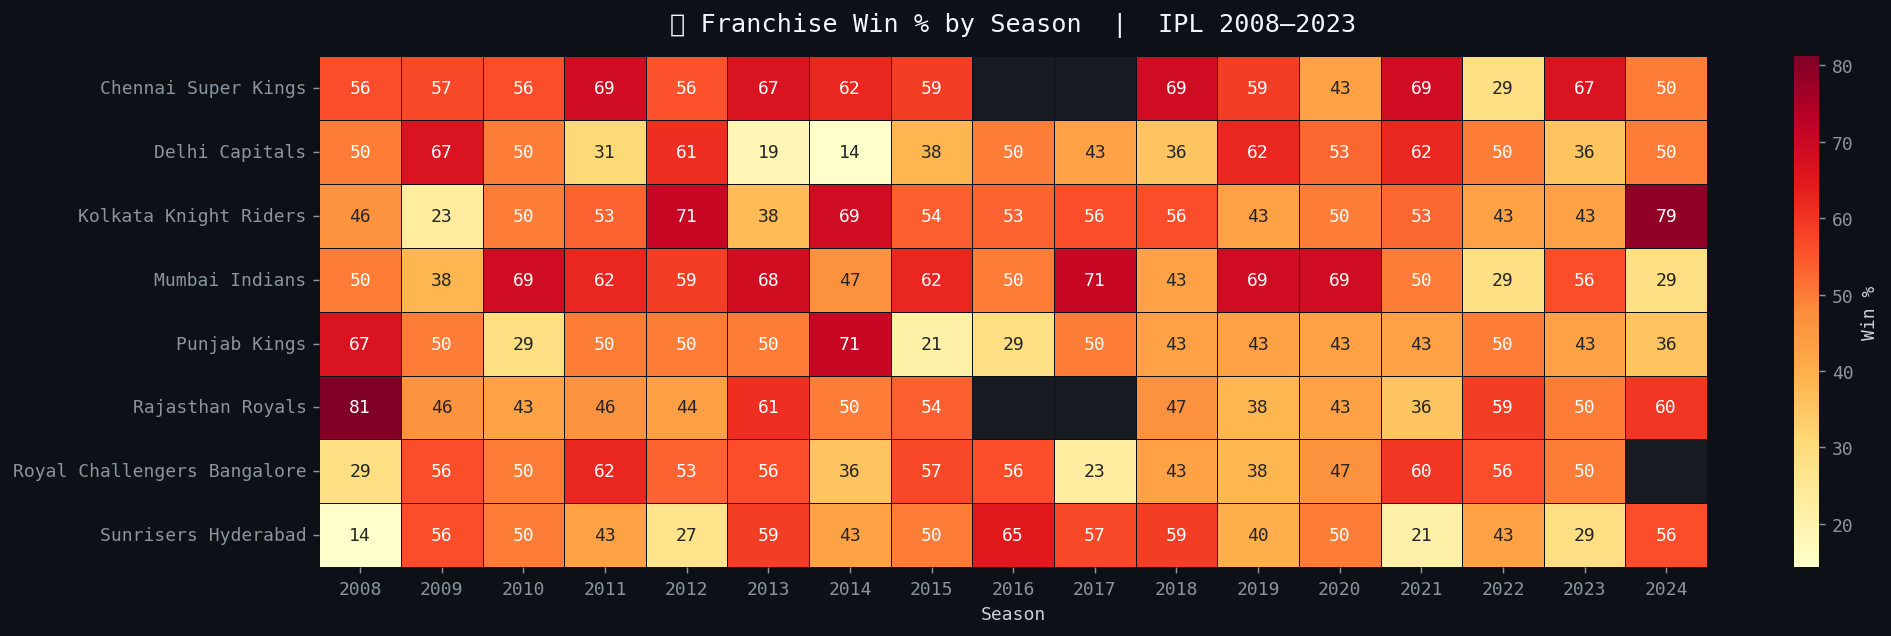


📌 INSIGHT: Mumbai Indians & CSK show consistently dark cells — sustained dominance.
   RCB shows high variance: great peaks, but many weak seasons (high risk franchise).


In [4]:
# ═══════════════════════════════════════════════════════════════
# BUSINESS QUESTION 1: Franchise Performance Over Seasons
# ═══════════════════════════════════════════════════════════════

team_season = (
    matches_clean.groupby(["season", "winner"])
    .size()
    .reset_index(name="wins")
)

# Total matches per team per season
total_matches = (
    matches_clean.melt(id_vars=["season"], value_vars=["team1", "team2"], value_name="team")
    .groupby(["season", "team"])
    .size()
    .reset_index(name="played")
)

franchise_stats = total_matches.merge(
    team_season.rename(columns={"winner": "team"}), on=["season", "team"], how="left"
).fillna({"wins": 0})
franchise_stats["win_pct"] = (franchise_stats["wins"] / franchise_stats["played"] * 100).round(1)

# Plot: Win % heatmap for top 8 teams
top_teams = ["Mumbai Indians", "Chennai Super Kings", "Kolkata Knight Riders",
             "Royal Challengers Bangalore", "Sunrisers Hyderabad", "Delhi Capitals",
             "Rajasthan Royals", "Punjab Kings"]

heatmap_data = franchise_stats[franchise_stats["team"].isin(top_teams)].pivot(
    index="team", columns="season", values="win_pct"
)

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(
    heatmap_data, annot=True, fmt=".0f", cmap="YlOrRd",
    linewidths=0.5, linecolor="#0d1117", ax=ax,
    cbar_kws={"label": "Win %"}
)
ax.set_title("🏆 Franchise Win % by Season  |  IPL 2008–2023", fontsize=14, pad=14, color="#f0f6fc")
ax.set_xlabel("Season", fontsize=10)
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("../assets/q1_win_pct_heatmap.png", bbox_inches="tight", facecolor="#0d1117")
plt.show()
print("\n📌 INSIGHT: Mumbai Indians & CSK show consistently dark cells — sustained dominance.")
print("   RCB shows high variance: great peaks, but many weak seasons (high risk franchise).")

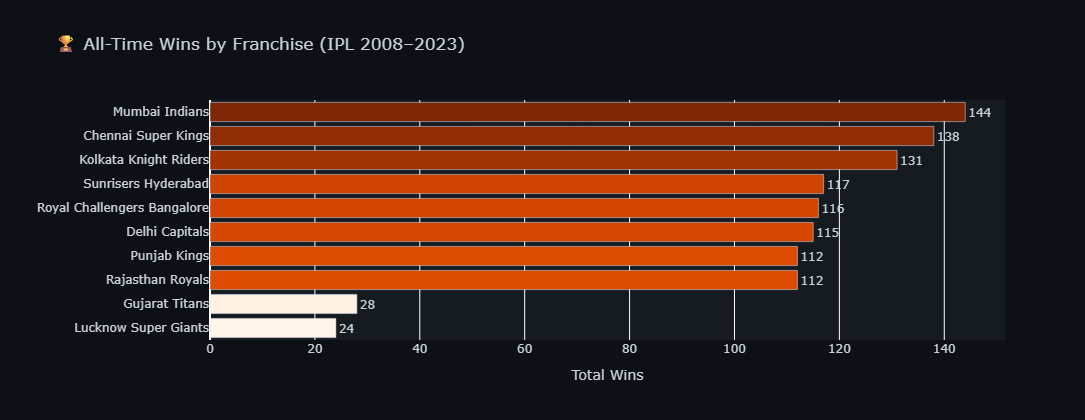

In [5]:
# Overall win count bar (all-time)
all_time_wins = (
    matches_clean["winner"]
    .value_counts()
    .head(10)
    .reset_index()
)
all_time_wins.columns = ["team", "wins"]

fig = px.bar(
    all_time_wins, x="wins", y="team", orientation="h",
    color="wins", color_continuous_scale="Oranges",
    title="🏆 All-Time Wins by Franchise (IPL 2008–2023)",
    labels={"wins": "Total Wins", "team": ""},
    text="wins"
)
fig.update_traces(textposition="outside")
fig.update_layout(
    plot_bgcolor="#161b22", paper_bgcolor="#0d1117",
    font_color="#c9d1d9", yaxis={"categoryorder": "total ascending"},
    coloraxis_showscale=False, height=420
)
fig.write_html("../assets/q1_alltime_wins.html")
fig.show()

In [6]:
# ═══════════════════════════════════════════════════════════════
# BUSINESS QUESTION 2: Phase-wise Match Dynamics
# (Powerplay / Middle / Death — where matches are won)
# ═══════════════════════════════════════════════════════════════

def assign_phase(over):
    if over <= 6:
        return "Powerplay (1-6)"
    elif over <= 15:
        return "Middle (7-15)"
    else:
        return "Death (16-20)"

deliveries["phase"] = deliveries["over"].apply(assign_phase)

phase_runs = (
    deliveries.groupby(["match_id", "batting_team", "phase"])["total_runs"]
    .sum()
    .reset_index()
)

phase_avg = (
    phase_runs.groupby(["batting_team", "phase"])["total_runs"]
    .mean()
    .reset_index()
)
phase_avg = phase_avg[phase_avg["batting_team"].isin(top_teams)]

fig = px.bar(
    phase_avg, x="batting_team", y="total_runs", color="phase",
    barmode="group",
    title="📊 Average Runs per Phase by Franchise",
    labels={"total_runs": "Avg Runs", "batting_team": "", "phase": "Phase"},
    color_discrete_map={
        "Powerplay (1-6)": "#58a6ff",
        "Middle (7-15)": "#3fb950",
        "Death (16-20)": "#f85149"
    }
)
fig.update_layout(
    plot_bgcolor="#161b22", paper_bgcolor="#0d1117",
    font_color="#c9d1d9", xaxis_tickangle=-30,
    legend_title_text="Phase", height=450
)
fig.write_html("../assets/q2_phase_runs.html")
fig.show()

print("\n📌 INSIGHT: Death-over scoring separates winners from losers.")
print("   Teams with high 'Death' bars win more run-chases. CSK excels in powerplay (calculated starts).")


📌 INSIGHT: Death-over scoring separates winners from losers.
   Teams with high 'Death' bars win more run-chases. CSK excels in powerplay (calculated starts).


In [7]:
# Wickets per phase — bowling efficiency
phase_wickets = (
    deliveries[deliveries["player_dismissed"].notna()]
    .groupby(["match_id", "bowling_team", "phase"])
    .size()
    .reset_index(name="wickets")
)
phase_wkt_avg = (
    phase_wickets.groupby(["bowling_team", "phase"])["wickets"]
    .mean()
    .reset_index()
)
phase_wkt_avg = phase_wkt_avg[phase_wkt_avg["bowling_team"].isin(top_teams)]

fig = px.bar(
    phase_wkt_avg, x="bowling_team", y="wickets", color="phase",
    barmode="group",
    title="🎯 Average Wickets per Phase by Franchise (Bowling)",
    labels={"wickets": "Avg Wickets", "bowling_team": "", "phase": "Phase"},
    color_discrete_map={
        "Powerplay (1-6)": "#58a6ff",
        "Middle (7-15)": "#3fb950",
        "Death (16-20)": "#f85149"
    }
)
fig.update_layout(
    plot_bgcolor="#161b22", paper_bgcolor="#0d1117",
    font_color="#c9d1d9", xaxis_tickangle=-30, height=450
)
fig.write_html("../assets/q2_phase_wickets.html")
fig.show()

In [8]:
# ═══════════════════════════════════════════════════════════════
# BUSINESS QUESTION 3: Toss Bias — Real or Myth?
# ═══════════════════════════════════════════════════════════════

matches_clean["toss_won_match"] = matches_clean["toss_winner"] == matches_clean["winner"]

toss_overall = matches_clean["toss_won_match"].mean() * 100
print(f"🎲 Toss winner also won the match: {toss_overall:.1f}% of the time")
print(f"   (Random baseline = 50%) → Toss edge = {toss_overall - 50:.1f}%")

# By toss decision
toss_decision = (
    matches_clean.groupby("toss_decision")["toss_won_match"]
    .agg(["mean", "count"])
    .reset_index()
)
toss_decision["win_pct"] = (toss_decision["mean"] * 100).round(1)
print("\n", toss_decision[["toss_decision", "win_pct", "count"]])

# Season trend
toss_season = (
    matches_clean.groupby("season")["toss_won_match"]
    .mean()
    .reset_index()
)
toss_season["win_pct"] = toss_season["toss_won_match"] * 100

fig = px.line(
    toss_season, x="season", y="win_pct",
    markers=True,
    title="🎲 Toss-to-Win Conversion % by Season",
    labels={"win_pct": "Win % after winning toss", "season": "Season"}
)
fig.add_hline(y=50, line_dash="dash", line_color="#f85149",
              annotation_text="50% baseline (pure luck)", annotation_position="top left")
fig.update_traces(line_color="#58a6ff", marker=dict(size=8))
fig.update_layout(
    plot_bgcolor="#161b22", paper_bgcolor="#0d1117",
    font_color="#c9d1d9", height=400
)
fig.write_html("../assets/q3_toss_bias.html")
fig.show()

print("\n📌 INSIGHT: Toss advantage is real but overstated (~52-55%).")
print("   Teams that field first win slightly more — dew factor & pitch use matter.")

🎲 Toss winner also won the match: 50.8% of the time
   (Random baseline = 50%) → Toss edge = 0.8%

   toss_decision  win_pct  count
0           bat     45.4    390
1         field     53.9    700



📌 INSIGHT: Toss advantage is real but overstated (~52-55%).
   Teams that field first win slightly more — dew factor & pitch use matter.


In [9]:
# ═══════════════════════════════════════════════════════════════
# BUSINESS QUESTION 4: Venue Analysis — Batsman vs Bowler Grounds
# ═══════════════════════════════════════════════════════════════

venue_runs = (
    deliveries.merge(matches_clean[["id", "venue"]], left_on="match_id", right_on="id")
    .groupby(["match_id", "venue", "inning"])["total_runs"]
    .sum()
    .reset_index()
)

venue_avg = (
    venue_runs.groupby("venue")["total_runs"]
    .agg(["mean", "count"])
    .reset_index()
)
venue_avg.columns = ["venue", "avg_score", "innings"]
venue_avg = venue_avg[venue_avg["innings"] >= 10]  # min 5 matches

venue_avg = venue_avg.sort_values("avg_score", ascending=False)

fig = px.bar(
    venue_avg.head(15), x="avg_score", y="venue", orientation="h",
    color="avg_score", color_continuous_scale="RdYlGn",
    title="🏟️ Average Innings Score by Venue (Top 15)",
    labels={"avg_score": "Avg Innings Score", "venue": ""},
    text=venue_avg.head(15)["avg_score"].round(0).astype(int)
)
fig.update_traces(textposition="outside")
fig.update_layout(
    plot_bgcolor="#161b22", paper_bgcolor="#0d1117",
    font_color="#c9d1d9", yaxis={"categoryorder": "total ascending"},
    coloraxis_showscale=False, height=500
)
fig.write_html("../assets/q4_venue_scores.html")
fig.show()

print("\n📌 INSIGHT: Venues like Chinnaswamy (Bengaluru) are batting paradises.")
print("   Low-scoring venues (Chepauk, Kotla) reward teams with strong bowling attacks.")


📌 INSIGHT: Venues like Chinnaswamy (Bengaluru) are batting paradises.
   Low-scoring venues (Chepauk, Kotla) reward teams with strong bowling attacks.


In [10]:
# ═══════════════════════════════════════════════════════════════
# BUSINESS QUESTION 5: Player Efficiency — Hidden Value Players
# ═══════════════════════════════════════════════════════════════

# Batting: Strike Rate vs Total Runs (bubble = consistency = matches played)
batsmen = (
    deliveries[deliveries["batsman_runs"] >= 0]
    .groupby("batter")
    .agg(
        total_runs=("batsman_runs", "sum"),
        balls_faced=("batsman_runs", "count"),
        innings=("match_id", "nunique")
    )
    .reset_index()
)
batsmen["strike_rate"] = (batsmen["total_runs"] / batsmen["balls_faced"] * 100).round(1)
batsmen["avg_runs_per_innings"] = (batsmen["total_runs"] / batsmen["innings"]).round(1)

# Filter: min 30 innings for meaningful stats
batsmen_filtered = batsmen[batsmen["innings"] >= 30].copy()

fig = px.scatter(
    batsmen_filtered,
    x="avg_runs_per_innings", y="strike_rate",
    size="total_runs", color="total_runs",
    hover_name="batter",
    color_continuous_scale="Plasma",
    title="⚡ Batting Efficiency Matrix — Avg Runs vs Strike Rate (min 30 innings)",
    labels={
        "avg_runs_per_innings": "Avg Runs per Innings",
        "strike_rate": "Strike Rate",
        "total_runs": "Total Career Runs"
    }
)
# Add quadrant lines
fig.add_hline(y=batsmen_filtered["strike_rate"].median(), line_dash="dash",
              line_color="#8b949e", annotation_text="Median SR")
fig.add_vline(x=batsmen_filtered["avg_runs_per_innings"].median(), line_dash="dash",
              line_color="#8b949e", annotation_text="Median Avg")
fig.update_layout(
    plot_bgcolor="#161b22", paper_bgcolor="#0d1117",
    font_color="#c9d1d9", height=520
)
fig.write_html("../assets/q5_batting_efficiency.html")
fig.show()

print("\n📌 INSIGHT: Top-right quadrant = elite impact players (high avg + high SR).")
print("   Bottom-right = anchor batters. Top-left = aggressive but inconsistent.")


📌 INSIGHT: Top-right quadrant = elite impact players (high avg + high SR).
   Bottom-right = anchor batters. Top-left = aggressive but inconsistent.


In [11]:
# Bowling efficiency: Economy + Strike Rate
bowlers = (
    deliveries[deliveries["bowler"].notna()]
    .groupby("bowler")
    .agg(
        wickets=("player_dismissed", lambda x: x.notna().sum()),
        runs_conceded=("total_runs", "sum"),
        balls_bowled=("total_runs", "count"),
        matches=("match_id", "nunique")
    )
    .reset_index()
)
bowlers["economy"] = (bowlers["runs_conceded"] / (bowlers["balls_bowled"] / 6)).round(2)
bowlers["bowling_sr"] = (bowlers["balls_bowled"] / bowlers["wickets"].replace(0, np.nan)).round(1)
bowlers_filtered = bowlers[(bowlers["matches"] >= 20) & (bowlers["wickets"] >= 20)].copy()

fig = px.scatter(
    bowlers_filtered,
    x="economy", y="bowling_sr",
    size="wickets", color="wickets",
    hover_name="bowler",
    color_continuous_scale="Blues",
    title="🎯 Bowling Efficiency Matrix — Economy vs Strike Rate (min 20 matches)",
    labels={"economy": "Economy Rate", "bowling_sr": "Bowling Strike Rate (lower=better)", "wickets": "Total Wickets"}
)
fig.add_hline(y=bowlers_filtered["bowling_sr"].median(), line_dash="dash", line_color="#8b949e")
fig.add_vline(x=bowlers_filtered["economy"].median(), line_dash="dash", line_color="#8b949e")
fig.update_layout(
    plot_bgcolor="#161b22", paper_bgcolor="#0d1117",
    font_color="#c9d1d9", height=520
)
fig.write_html("../assets/q5_bowling_efficiency.html")
fig.show()

print("\n📌 INSIGHT: Bottom-left = elite bowlers (low economy + low SR = cheap wicket-takers).")


📌 INSIGHT: Bottom-left = elite bowlers (low economy + low SR = cheap wicket-takers).


In [12]:
# ═══════════════════════════════════════════════════════════════
# EXPORT: Aggregated CSVs for Power BI
# ═══════════════════════════════════════════════════════════════

franchise_stats.to_csv("../powerbi_exports/franchise_season_stats.csv", index=False)
phase_avg.to_csv("../powerbi_exports/phase_runs_by_team.csv", index=False)
toss_season.to_csv("../powerbi_exports/toss_win_by_season.csv", index=False)
venue_avg.to_csv("../powerbi_exports/venue_avg_scores.csv", index=False)
batsmen_filtered.to_csv("../powerbi_exports/batsmen_efficiency.csv", index=False)
bowlers_filtered.to_csv("../powerbi_exports/bowlers_efficiency.csv", index=False)

print("✅ All CSVs exported to /powerbi_exports/ — ready for Power BI!")
print("\n🏁 EDA Complete. Key files:")
print("   assets/   → PNG charts for README")
print("   assets/   → HTML interactive charts")
print("   powerbi_exports/ → CSVs for Power BI")

✅ All CSVs exported to /powerbi_exports/ — ready for Power BI!

🏁 EDA Complete. Key files:
   assets/   → PNG charts for README
   assets/   → HTML interactive charts
   powerbi_exports/ → CSVs for Power BI
